In [2]:
#Open spectrometer files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Scope Corrected for Dark'] = pd.to_numeric(df['Scope Corrected for Dark'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
def graficar_datos(df, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    plt.plot(df[columna_x], df[columna_y], marker='.', linestyle='-')
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x}")
    plt.grid()
    plt.show()


def graficar_multiples_dfs(lista_dfs, nombres, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    for df, nombre in zip(lista_dfs, nombres):
        if df is not None and columna_x in df.columns and columna_y in df.columns:
            plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-', markersize=3, linewidth=0.8, label=nombre)
        else:
            print(f"Error: No se pudo graficar {nombre}, columnas no encontradas")
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x} de los 4 espectrómetros")
    plt.legend()
    plt.minorticks_on()  # Habilitar las marcas menores
    plt.grid(which='both', linestyle='-', linewidth=0.5, alpha=0.7)
    # Ajustar los márgenes de manera manual
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
    plt.show()


In [3]:
UV1 = "2.E2E_olivine/Olivine_LIBS_shot01_7324767SP.txt" 
UV2 = "2.E2E_olivine/Olivine_LIBS_shot01_7324768SP.txt" 
VIS = "2.E2E_olivine/Olivine_LIBS_shot01_7324769SP.txt" 
NIR = "2.E2E_olivine/Olivine_LIBS_shot01_7324770SP.txt" 

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)

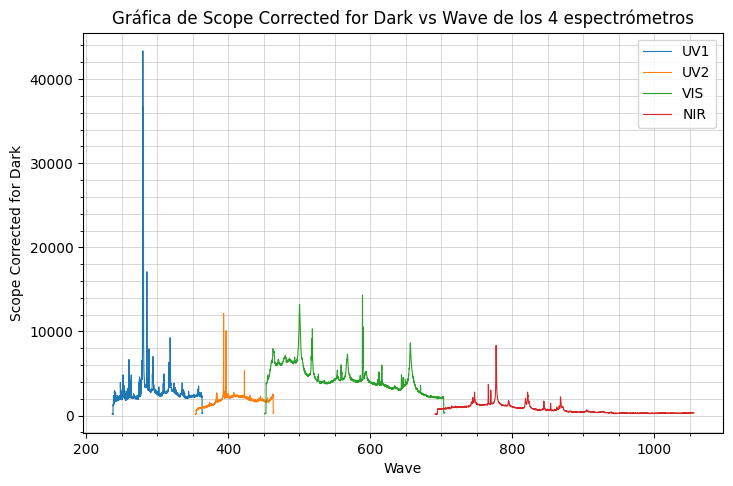

In [4]:

if datos_UV1 is not None and datos_UV2 is not None and datos_VIS is not None and datos_NIR is not None:
    # Lista de DataFrames y nombres
    dfs = [datos_UV1, datos_UV2, datos_VIS, datos_NIR]
    nombres = ["UV1", "UV2", "VIS", "NIR"]
    # Llamar a la función de graficado
    graficar_multiples_dfs(dfs, nombres, 'Wave', 'Scope Corrected for Dark')
else:
    print("Error")


# Definir los intervalos y los archivos asociados a cada uno
intervalos = {
    "Intervalo 1 (353.53-363.79 nm)": [datos_UV1, datos_UV2],   # Solo afecta UV1 y UV2
    "Intervalo 2 (450.96-463.86 nm)": [datos_UV2, datos_VIS],   # Solo afecta UV2 y VIS
    "Intervalo 3 (691.50-705.11 nm)": [datos_VIS, datos_NIR]    # Solo afecta VIS y NIR
}

In [6]:
medianas = {}

for intervalo, archivos in intervalos.items():
    medianas[intervalo] = {}  # Crear diccionario para cada intervalo
    
    for i, df in enumerate(archivos):
        if df is not None:
            min_wave, max_wave = map(float, intervalo.split("(")[1].split("nm")[0].split("-"))
            df_filtrado = df[(df['Wave'] >= min_wave) & (df['Wave'] <= max_wave)]
            
            if not df_filtrado.empty:
                mediana_y = df_filtrado['Scope Corrected for Dark'].median()
            else:
                mediana_y = None
            
            # Guardar la mediana asociada al archivo
            medianas[intervalo][f"Archivo {i+1}"] = mediana_y


medianas


{'Intervalo 1 (353.53-363.79 nm)': {'Archivo 1': np.float64(2359.45),
  'Archivo 2': np.float64(849.6)},
 'Intervalo 2 (450.96-463.86 nm)': {'Archivo 1': np.float64(1746.6),
  'Archivo 2': np.float64(4729.55)},
 'Intervalo 3 (691.50-705.11 nm)': {'Archivo 1': np.float64(2127.55),
  'Archivo 2': np.float64(775.25)}}

In [8]:
# Calcular los coeficientes basados en las medianas
coeficientes = []

for intervalo, resultados in medianas.items():
    # Verificamos que tengamos al menos dos archivos para calcular el coeficiente
    if len(resultados) >= 2:
        archivo_1, archivo_2 = list(resultados.values())[:2]  # Tomamos las medianas de los dos primeros archivos
        if archivo_1 is not None and archivo_2 is not None:
            # Calculamos el coeficiente
            coeficiente = archivo_1 / archivo_2  # Aquí puedes poner cualquier operación que desees
            coeficientes.append(coeficiente)
coeficientes

[np.float64(2.777130414312617),
 np.float64(0.3692951760738336),
 np.float64(2.7443405353111903)]

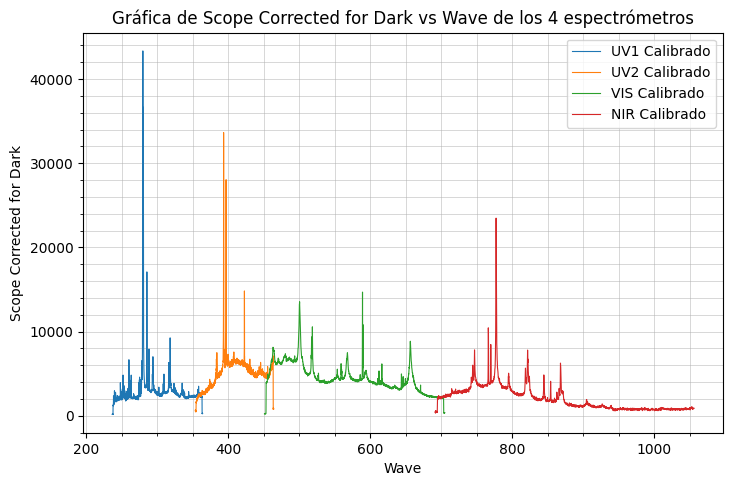

In [10]:

datos_UV1_corr = datos_UV1.copy()
datos_UV2_corr = datos_UV2.copy()
datos_VIS_corr = datos_VIS.copy()
datos_NIR_corr = datos_NIR.copy()

datos_UV1_corr['Scope Corrected for Dark'] = datos_UV1['Scope Corrected for Dark']
datos_UV2_corr['Scope Corrected for Dark'] = datos_UV2['Scope Corrected for Dark']*coeficientes[0]
datos_VIS_corr['Scope Corrected for Dark'] = datos_VIS['Scope Corrected for Dark']*coeficientes[1]*coeficientes[0]
datos_NIR_corr['Scope Corrected for Dark'] = datos_NIR['Scope Corrected for Dark']*coeficientes[2]*coeficientes[1]*coeficientes[0]

dfs_calibrados = [datos_UV1_corr, datos_UV2_corr, datos_VIS_corr, datos_NIR_corr]
nombres_calibrados = ["UV1 Calibrado", "UV2 Calibrado", "VIS Calibrado", "NIR Calibrado"]
graficar_multiples_dfs(dfs_calibrados, nombres_calibrados, 'Wave', 'Scope Corrected for Dark')


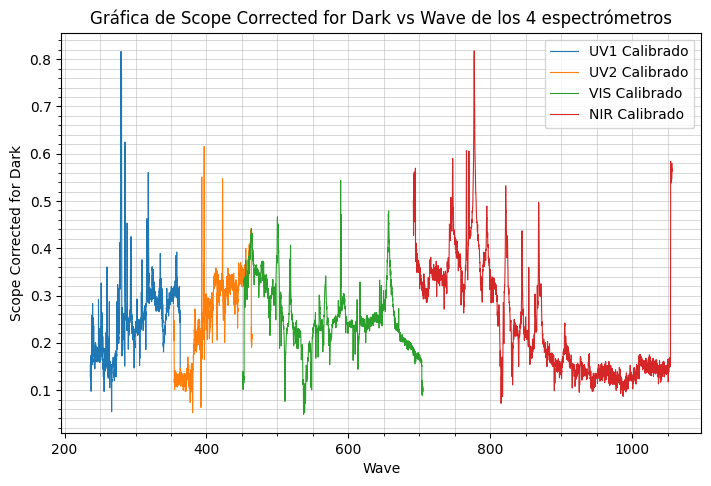

In [135]:

datos_UV1_norm = datos_UV1_corr
datos_UV2_norm = datos_UV2_corr
datos_VIS_norm = datos_VIS_corr
datos_NIR_norm = datos_NIR_corr

norm = sum([datos_UV1_corr['Scope Corrected for Dark'],datos_UV2_corr['Scope Corrected for Dark'],datos_VIS_corr['Scope Corrected for Dark'],datos_NIR_corr['Scope Corrected for Dark']])
datos_UV1_norm['Scope Corrected for Dark'] = datos_UV1_corr['Scope Corrected for Dark']/norm
datos_UV2_norm['Scope Corrected for Dark'] = datos_UV2_corr['Scope Corrected for Dark']/norm
datos_VIS_norm['Scope Corrected for Dark'] = datos_VIS_corr['Scope Corrected for Dark']/norm
datos_NIR_norm['Scope Corrected for Dark'] = datos_NIR_corr['Scope Corrected for Dark']/norm

dfs_normalizados = [datos_UV1_norm, datos_UV2_norm, datos_VIS_norm, datos_NIR_norm]
graficar_multiples_dfs(dfs_normalizados, nombres_calibrados, 'Wave', 'Scope Corrected for Dark')


0       0.000222
1       0.000259
2       0.000196
3       0.000264
4       0.000190
          ...   
2043    0.000391
2044    0.000391
2045    0.000385
2046    0.000391
2047    0.000382
Name: Scope Corrected for Dark, Length: 2048, dtype: float64